# SSM Trajectory Predictor — Test Notebook

Load a checkpoint, evaluate ADE/FDE, and explore predictions interactively.

In [1]:
import sys
import os
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# make sure ssm/ is on the path so model.py and s4d.py are importable
SSM_DIR = Path(".").resolve()
if str(SSM_DIR) not in sys.path:
    sys.path.insert(0, str(SSM_DIR))

from model import TrajectoryPredictor

OBSERVE_LEN = 8
PREDICT_LEN = 12
BATCH_SIZE  = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Config — change these to switch checkpoints or scenes

In [2]:
# List available checkpoints
CHECKPOINT_DIR = SSM_DIR / "checkpoints"
checkpoints = sorted(CHECKPOINT_DIR.rglob("*best_model.pt"))
print("Available checkpoints:")
for i, p in enumerate(checkpoints):
    print(f"  [{i}] {p.relative_to(SSM_DIR)}")

Available checkpoints:
  [0] checkpoints\lr_0.001_batch_64_epochs_100_best_model.pt
  [1] checkpoints\lr_0.003_batch_512_epochs_100_best_model.pt
  [2] checkpoints\v1\lr_0.005_batch_64_epochs_100_best_model.pt


In [3]:
# ── Pick your scenario here ───────────────────────────────────────────────
CHECKPOINT_IDX = 1          # index from the list above
SCENE          = "eth"       # eth | hotel | univ | zara1 | zara2
SPLIT          = "test"      # test | val | train
# ─────────────────────────────────────────────────────────────────────────

CHECKPOINT_PATH = checkpoints[CHECKPOINT_IDX]
DATA_PATH       = SSM_DIR.parent / "datasets_processed" / SCENE / f"{SPLIT}.pt"

print(f"Checkpoint : {CHECKPOINT_PATH}")
print(f"Data       : {DATA_PATH}")

Checkpoint : C:\VSCode\Classes\PIC16B\robotic_prediction_comparison\ssm\checkpoints\lr_0.003_batch_512_epochs_100_best_model.pt
Data       : C:\VSCode\Classes\PIC16B\robotic_prediction_comparison\datasets_processed\eth\test.pt


## Load data and model

In [4]:
data = torch.load(DATA_PATH)
print(f"Loaded {data.shape[0]} trajectories from {DATA_PATH.name}  shape={tuple(data.shape)}")

model = TrajectoryPredictor().to(device)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(f"Loaded model from {CHECKPOINT_PATH.name}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Loaded 364 trajectories from test.pt  shape=(364, 20, 2)
Loaded model from lr_0.003_batch_512_epochs_100_best_model.pt
Parameters: 67,266


## Run predictions

In [5]:
def build_model_input(traj):
    inp = torch.zeros_like(traj)
    inp[:, 1:OBSERVE_LEN, :] = traj[:, 1:OBSERVE_LEN, :] - traj[:, :OBSERVE_LEN - 1, :]
    return inp


loader = DataLoader(TensorDataset(data), batch_size=BATCH_SIZE, shuffle=False)
all_preds, all_gt = [], []

with torch.no_grad():
    for (batch,) in loader:
        batch      = batch.to(device)
        raw_output = model(build_model_input(batch))

        last_obs      = batch[:, OBSERVE_LEN - 1:OBSERVE_LEN, :]   # (B, 1, 2)
        pred_deltas   = raw_output[:, OBSERVE_LEN:, :]              # (B, 12, 2)
        pred_future   = last_obs + pred_deltas.cumsum(dim=1)        # (B, 12, 2)

        preds = batch.clone()
        preds[:, OBSERVE_LEN:, :] = pred_future

        all_preds.append(preds.cpu())
        all_gt.append(batch.cpu())

all_preds = torch.cat(all_preds, dim=0)   # (N, 20, 2)
all_gt    = torch.cat(all_gt,    dim=0)   # (N, 20, 2)
print(f"Predictions shape: {tuple(all_preds.shape)}")

Predictions shape: (364, 20, 2)


## ADE / FDE

In [6]:
pred_future = all_preds[:, OBSERVE_LEN:, :]   # (N, 12, 2)
true_future = all_gt[:,   OBSERVE_LEN:, :]    # (N, 12, 2)

l2_per_step = torch.norm(pred_future - true_future, dim=-1)   # (N, 12)
ade_per_traj = l2_per_step.mean(dim=1)                        # (N,)
fde_per_traj = l2_per_step[:, -1]                             # (N,)

ade = ade_per_traj.mean().item()
fde = fde_per_traj.mean().item()

print(f"Scene: {SCENE}  |  Split: {SPLIT}  |  N={all_gt.shape[0]}")
print(f"  ADE (mean L2 over 12 steps): {ade:.4f} m")
print(f"  FDE (L2 at final step):      {fde:.4f} m")
print(f"  ADE 50th pct:                {ade_per_traj.median().item():.4f} m")
print(f"  ADE 90th pct:                {torch.quantile(ade_per_traj, 0.9).item():.4f} m")

Scene: eth  |  Split: test  |  N=364
  ADE (mean L2 over 12 steps): 1.0147 m
  FDE (L2 at final step):      2.0313 m
  ADE 50th pct:                0.8313 m
  ADE 90th pct:                2.0536 m


## Error distribution

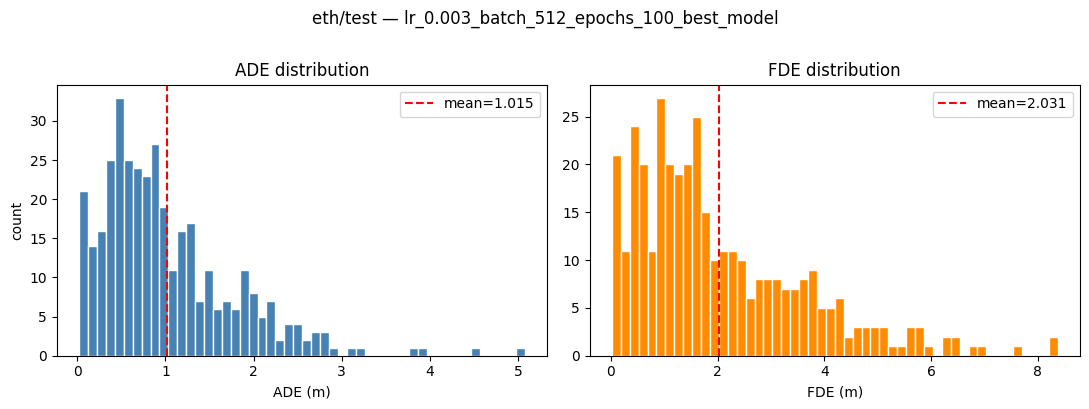

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(ade_per_traj.numpy(), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(ade, color="red", linestyle="--", label=f"mean={ade:.3f}")
axes[0].set_title("ADE distribution")
axes[0].set_xlabel("ADE (m)")
axes[0].set_ylabel("count")
axes[0].legend()

axes[1].hist(fde_per_traj.numpy(), bins=50, color="darkorange", edgecolor="white")
axes[1].axvline(fde, color="red", linestyle="--", label=f"mean={fde:.3f}")
axes[1].set_title("FDE distribution")
axes[1].set_xlabel("FDE (m)")
axes[1].legend()

plt.suptitle(f"{SCENE}/{SPLIT} — {CHECKPOINT_PATH.stem}", y=1.01)
plt.tight_layout()
plt.show()

## Plot example trajectories

Change `NUM_PLOT`, `SEED`, or `PICK_INDICES` to control what you see.
Set `PICK_INDICES` to a list of ints to select specific trajectories, or `None` to pick randomly.

In [ ]:
NUM_PLOT     = 9
SEED         = 1
PICK_INDICES = None   # e.g. [0, 5, 100] to hand-pick, or None for random

np.random.seed(SEED)
indices = PICK_INDICES if PICK_INDICES is not None else np.random.choice(len(all_preds), NUM_PLOT, replace=False)

n_cols = int(np.ceil(np.sqrt(len(indices))))
n_rows = int(np.ceil(len(indices) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).flatten()

for plot_i, traj_i in enumerate(indices):
    pred = all_preds[traj_i].numpy()
    gt   = all_gt[traj_i].numpy()

    obs       = gt[:OBSERVE_LEN]
    true_fut  = gt[OBSERVE_LEN:]
    pred_fut  = pred[OBSERVE_LEN:]

    ax = axes[plot_i]
    ax.plot(obs[:, 0],      obs[:, 1],      "ko-", label="Observed",    markersize=4)
    ax.plot(true_fut[:, 0], true_fut[:, 1], "g^-", label="True future", markersize=4)
    ax.plot(pred_fut[:, 0], pred_fut[:, 1], "rs-", label="Predicted",   markersize=4)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_title(f"#{traj_i}  ADE={ade_per_traj[traj_i]:.2f}")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_xlim(-12, 12)
    ax.set_ylim(-9, 9)
    ax.legend(fontsize=7)
    ax.set_aspect("equal")

for extra in range(len(indices), len(axes)):
    axes[extra].axis("off")

plt.suptitle(f"Predictions — {SCENE}/{SPLIT}  seed={SEED}", y=1.01)
plt.tight_layout()
plt.show()

## Best and worst predictions by ADE

In [ ]:
N_SHOW = 5   # how many best / worst to show

sorted_by_ade = torch.argsort(ade_per_traj)
best_indices  = sorted_by_ade[:N_SHOW].tolist()
worst_indices = sorted_by_ade[-N_SHOW:].tolist()

for label, indices in [("Best", best_indices), ("Worst", worst_indices)]:
    fig, axes = plt.subplots(1, N_SHOW, figsize=(4 * N_SHOW, 4))
    for ax, traj_i in zip(axes, indices):
        pred = all_preds[traj_i].numpy()
        gt   = all_gt[traj_i].numpy()
        obs       = gt[:OBSERVE_LEN]
        true_fut  = gt[OBSERVE_LEN:]
        pred_fut  = pred[OBSERVE_LEN:]
        ax.plot(obs[:, 0],      obs[:, 1],      "ko-", label="Observed", markersize=4)
        ax.plot(true_fut[:, 0], true_fut[:, 1], "g^-", label="True future", markersize=4)
        ax.plot(pred_fut[:, 0], pred_fut[:, 1], "rs-", label="Predicted", markersize=4)
        ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
        ax.set_title(f"#{traj_i}  ADE={ade_per_traj[traj_i]:.3f}")
        ax.set_aspect("equal")
        ax.set_xlabel("x (m)")
        ax.set_xlim(-12, 12)
        ax.set_ylim(-9, 9)
        ax.legend(fontsize=7)
    axes[0].set_ylabel("y (m)")
    plt.suptitle(f"{label} {N_SHOW} predictions by ADE — {SCENE}/{SPLIT}")
    plt.tight_layout()
    plt.show()

In [10]:
23

23